# Crop Yield Prediction - Model Evaluation

## 📊 Đánh Giá Kết Quả Cuối Cùng

Notebook này:
1. **Residual Analysis** - Phân tích dư số
2. **Model Comparison** - So sánh chi tiết
3. **Predictions Analysis** - Phân tích dự báo
4. **Key Insights** - Các thông tin quan trọng

---

In [1]:
import sys
from pathlib import Path

# Thêm src vào path để import modules
src_path = Path('../src')
sys.path.insert(0, str(src_path.absolute()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Import modules
from models.regression import RegressionModels
from evaluation.metrics import ModelMetrics, ResidualAnalysis
from evaluation.report import EvaluationReporter

print("✓ Đã import tất cả thư viện")

✓ Đã import tất cả thư viện


In [2]:
# Tải dữ liệu đã làm sạch (cleaned)
from data.loader import DataLoader

loader = DataLoader(data_dir="../data/raw", use_cleaned=True)
df, _ = loader.get_complete_dataset()

print("✓ Đã tải dữ liệu đã làm sạch")
print(f"   Shape: {df.shape}")


📊 BẮT ĐẦU TẢI DỮ LIỆU
📂 Đang đọc file (CLEANED): yield_cleaned.csv...
   ✓ Thành công! Shape: (56717, 12)
📂 Đang đọc file (CLEANED): pesticides_cleaned.csv...
   ✓ Thành công! Shape: (4349, 7)
📂 Đang đọc file (CLEANED): rainfall_cleaned.csv...
   ✓ Thành công! Shape: (5947, 3)
📂 Đang đọc file (CLEANED): temp_cleaned.csv...
   ✓ Thành công! Shape: (68764, 3)

✓ Đã tải 4 file dữ liệu!

🔗 KẾT HỢP CÁC DATASET
   Bắt đầu: yield (56717, 4)
   Sau merge pesticides: (24153, 5)
   Sau merge rainfall: (18949, 6)
   Sau merge temperature: (13130, 7)

✓ Kết hợp xong! Shape cuối cùng: (13130, 7)
✓ Đã tải dữ liệu đã làm sạch
   Shape: (13130, 7)


In [3]:
# Chuẩn bị data
target_col = 'Yield'
X = df.drop(columns=[target_col]).copy()
y = pd.to_numeric(df[target_col], errors='coerce')

# Encode tất cả biến phân loại (Area, Item, ...)
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
if categorical_cols:
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Đảm bảo toàn bộ feature là số
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

X = X.fillna(X.median(numeric_only=True))
y = y.fillna(y.median())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Huấn luyện models
regressor = RegressionModels()
models = regressor.create_models()
trained_models = regressor.train_models(X_train, y_train)

print(f"✓ Đã huấn luyện models")
print(f"   Số model train thành công: {len(trained_models)}")
print(f"   Feature count: {X.shape[1]}")


🏗️  TẠO CÁC MÔ HÌNH REGRESSION

   📌 BASELINE MODELS:
      • Linear Regression
      • Ridge Regression (alpha=5.0)

   🚀 ADVANCED MODELS:
      • Random Forest (300 estimators, tuned)
      • Extra Trees (400 estimators)
      • Hist Gradient Boosting (400 iterations)
      • XGBoost (skip - chưa cài package xgboost)

   ✓ Đã tạo 5 models

🎯 HUẤN LUYỆN CÁC MÔ HÌNH

   Training data shape: (10504, 113)
   ℹ️  Áp dụng log1p target transform để giảm ảnh hưởng outliers

   Linear Regression...
      ✓ Hoàn thành!

   Ridge Regression...
      ✓ Hoàn thành!

   Random Forest...
      ✓ Hoàn thành!

   Extra Trees...
      ✓ Hoàn thành!

   Hist Gradient Boosting...
      ✓ Hoàn thành!

   ✓ Đã huấn luyện 5/5 models
✓ Đã huấn luyện models
   Số model train thành công: 5
   Feature count: 113


## 1. Predictions & Residuals

In [4]:
# Dự báo từ tất cả models
predictions = {}
residuals = {}

for model_name, model in regressor.trained_models.items():
    y_pred = model.predict(X_test)
    predictions[model_name] = y_pred
    residuals[model_name] = y_test.values - y_pred

print(f"✓ Đã tạo predictions từ {len(predictions)} models")

✓ Đã tạo predictions từ 5 models


In [7]:
# Residual analysis
print("\n" + "="*80)
print("📊 RESIDUAL ANALYSIS")
print("="*80)

residual_analysis = ResidualAnalysis()

for model_name, y_pred in predictions.items():
    print(f"\n{model_name}:")
    residual_analysis.analyze_residuals(
        y_test.values,
        y_pred,
        model_name=model_name
    )


📊 RESIDUAL ANALYSIS

Linear Regression:

📈 PHÂN TÍCH RESIDUALS: Linear Regression

   🔹 Thống kê Residuals:
      • Mean:       5075.5596
      • Std Dev:    37725.3504
      • Min:        -214885.9713
      • Max:        325675.4224
      • Median:     802.7948

   🔹 Kiểm tra Tính Chuẩn:
      • Skewness:   0.1133 (roughly normal)

   🔹 Kiểm tra Homoscedasticity:
      • Std Dev First Half:  38335.4203
      • Std Dev Second Half: 37082.5351
      • Ratio: 1.0338

Ridge Regression:

📈 PHÂN TÍCH RESIDUALS: Ridge Regression

   🔹 Thống kê Residuals:
      • Mean:       6194.1533
      • Std Dev:    37095.8255
      • Min:        -177634.2678
      • Max:        323837.7100
      • Median:     1051.1695

   🔹 Kiểm tra Tính Chuẩn:
      • Skewness:   0.1386 (roughly normal)

   🔹 Kiểm tra Homoscedasticity:
      • Std Dev First Half:  37865.2370
      • Std Dev Second Half: 36286.5757
      • Ratio: 1.0435

Random Forest:

📈 PHÂN TÍCH RESIDUALS: Random Forest

   🔹 Thống kê Residuals:
  

## 2. Detailed Metrics

In [5]:
# Tính metrics chi tiết
print("\n" + "="*80)
print("📊 DETAILED MODEL METRICS")
print("="*80)

metrics_calculator = ModelMetrics()
all_metrics = {}

for model_name, y_pred in predictions.items():
    print(f"\n{model_name}:")
    print("-" * 40)
    
    metrics = metrics_calculator.calculate_metrics(y_test.values, y_pred, model_name=model_name)
    all_metrics[model_name] = metrics
    
    metrics_calculator.print_metrics(model_name)

# Tạo metrics dataframe
metrics_df = pd.DataFrame(all_metrics).T.sort_values('R2', ascending=False)

print("\n\n" + "="*80)
print("📊 COMPARISON TABLE")
print("="*80)
display(metrics_df)


📊 DETAILED MODEL METRICS

Linear Regression:
----------------------------------------

📊 METRICS: Linear Regression

   🔹 Regression Metrics:
      • MAE (Mean Absolute Error):     21961.5706
      • RMSE (Root Mean Squared Error): 38065.2514
      • MSE (Mean Squared Error):       1448963365.7052
      • R² (Coefficient of Determination): 0.7793

   🔹 Percentage Errors:
      • MAPE (Mean Absolute % Error): 0.4570

   🔹 Other Metrics:
      • MASE (Mean Absolute Scaled Error): 0.2782
      • MBE (Mean Bias Error):              5075.5596
      • Median AE (Median Absolute Error): 10356.3744

Ridge Regression:
----------------------------------------

📊 METRICS: Ridge Regression

   🔹 Regression Metrics:
      • MAE (Mean Absolute Error):     21871.6286
      • RMSE (Root Mean Squared Error): 37609.4111
      • MSE (Mean Squared Error):       1414467803.6520
      • R² (Coefficient of Determination): 0.7845

   🔹 Percentage Errors:
      • MAPE (Mean Absolute % Error): 0.4619

   🔹 Oth

,Model,MAE,RMSE,MSE,R2,MAPE,MASE,MBE,Median_AE
Extra Trees,Extra Trees,7830.039274,16386.837181,268528432.806859,0.959096,0.14719,0.099204,2727.515793,3105.455369
Hist Gradient Boosting,Hist Gradient Boosting,13092.219445,24645.436913,607397560.646906,0.907476,0.236662,0.165874,4182.799206,5573.520346
Random Forest,Random Forest,12902.28064,25938.4431,672802830.442467,0.897513,0.22213,0.163468,7853.733101,4898.655061
Ridge Regression,Ridge Regression,21871.628636,37609.411105,1414467803.651969,0.784536,0.461949,0.277107,6194.153275,10477.321648
Linear Regression,Linear Regression,21961.570635,38065.25142,1448963365.70516,0.779282,0.456978,0.278246,5075.559576,10356.374385


## 3. Actual vs Predicted

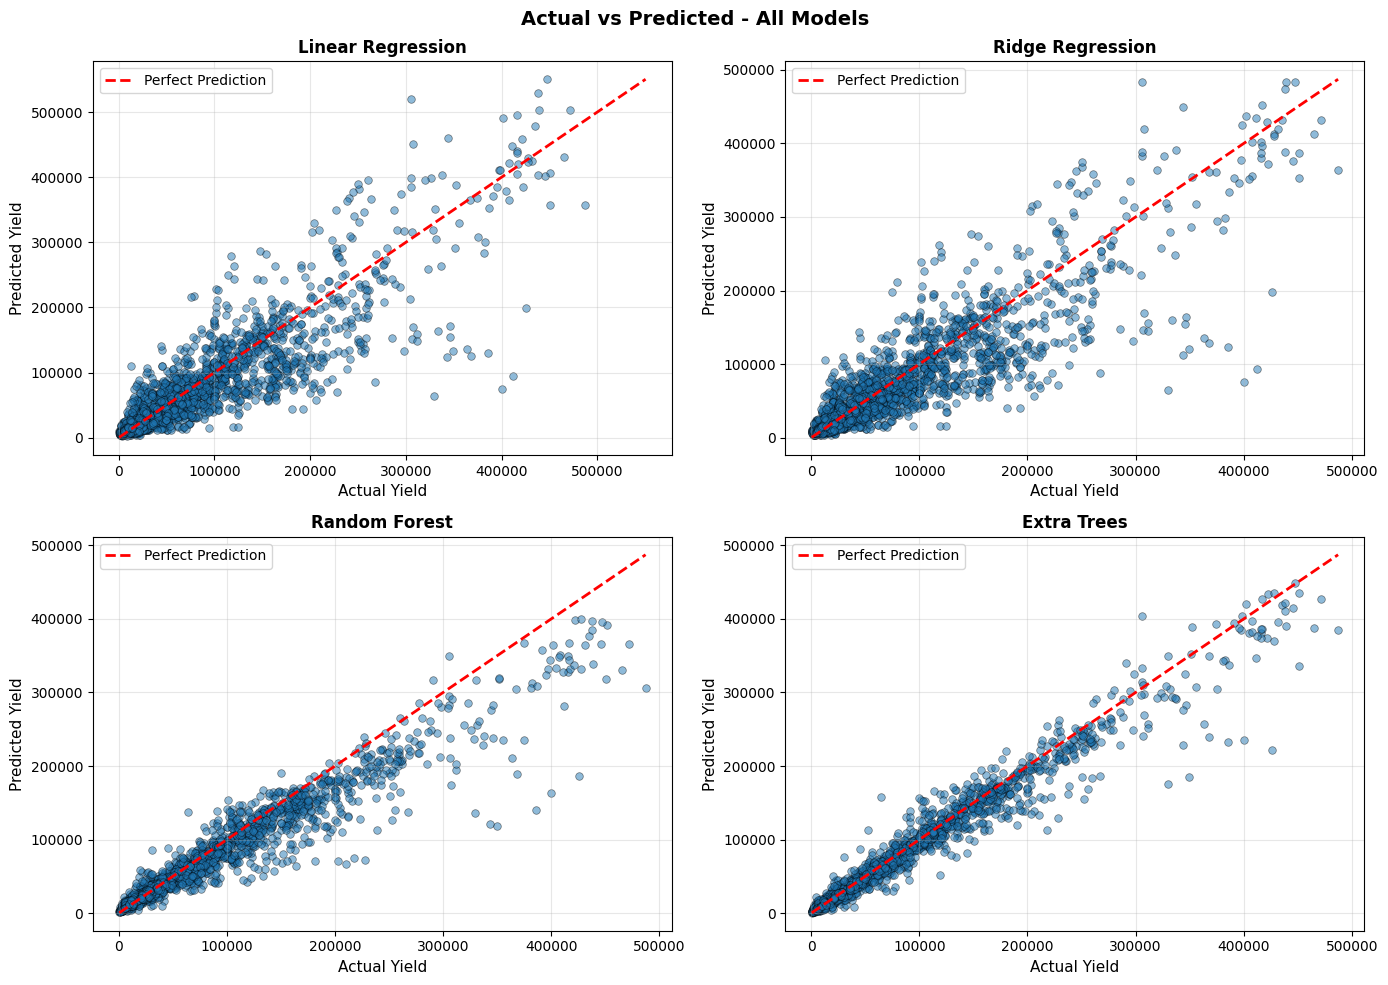

✓ Biểu đồ actual vs predicted đã vẽ


In [8]:
# Vẽ actual vs predicted cho tất cả models
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

model_names = list(predictions.keys())

for idx, model_name in enumerate(model_names[:4]):
    y_pred = predictions[model_name]
    
    # Scatter plot
    axes[idx].scatter(y_test, y_pred, alpha=0.5, s=30, edgecolors='k', linewidth=0.5)
    
    # Perfect prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
    
    axes[idx].set_xlabel('Actual Yield', fontsize=11)
    axes[idx].set_ylabel('Predicted Yield', fontsize=11)
    axes[idx].set_title(f'{model_name}', fontsize=12, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.suptitle('Actual vs Predicted - All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Biểu đồ actual vs predicted đã vẽ")

# Vẽ residuals distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, model_name in enumerate(model_names[:4]):
    resid = residuals[model_name]
    
    # Histogram
    axes[idx].hist(resid, bins=20, alpha=0.7, edgecolor='black', color='steelblue')
    axes[idx].axvline(x=0, color='r', linestyle='--', linewidth=2, label='Zero Error')
    
    axes[idx].set_xlabel('Residuals', fontsize=11)
    axes[idx].set_ylabel('Frequency', fontsize=11)
    axes[idx].set_title(f'{model_name} (Mean: {resid.mean():.4f}, Std: {resid.std():.4f})', 
                       fontsize=11, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3, axis='y')

plt.suptitle('Residuals Distribution - All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Biểu đồ residuals distribution đã vẽ")

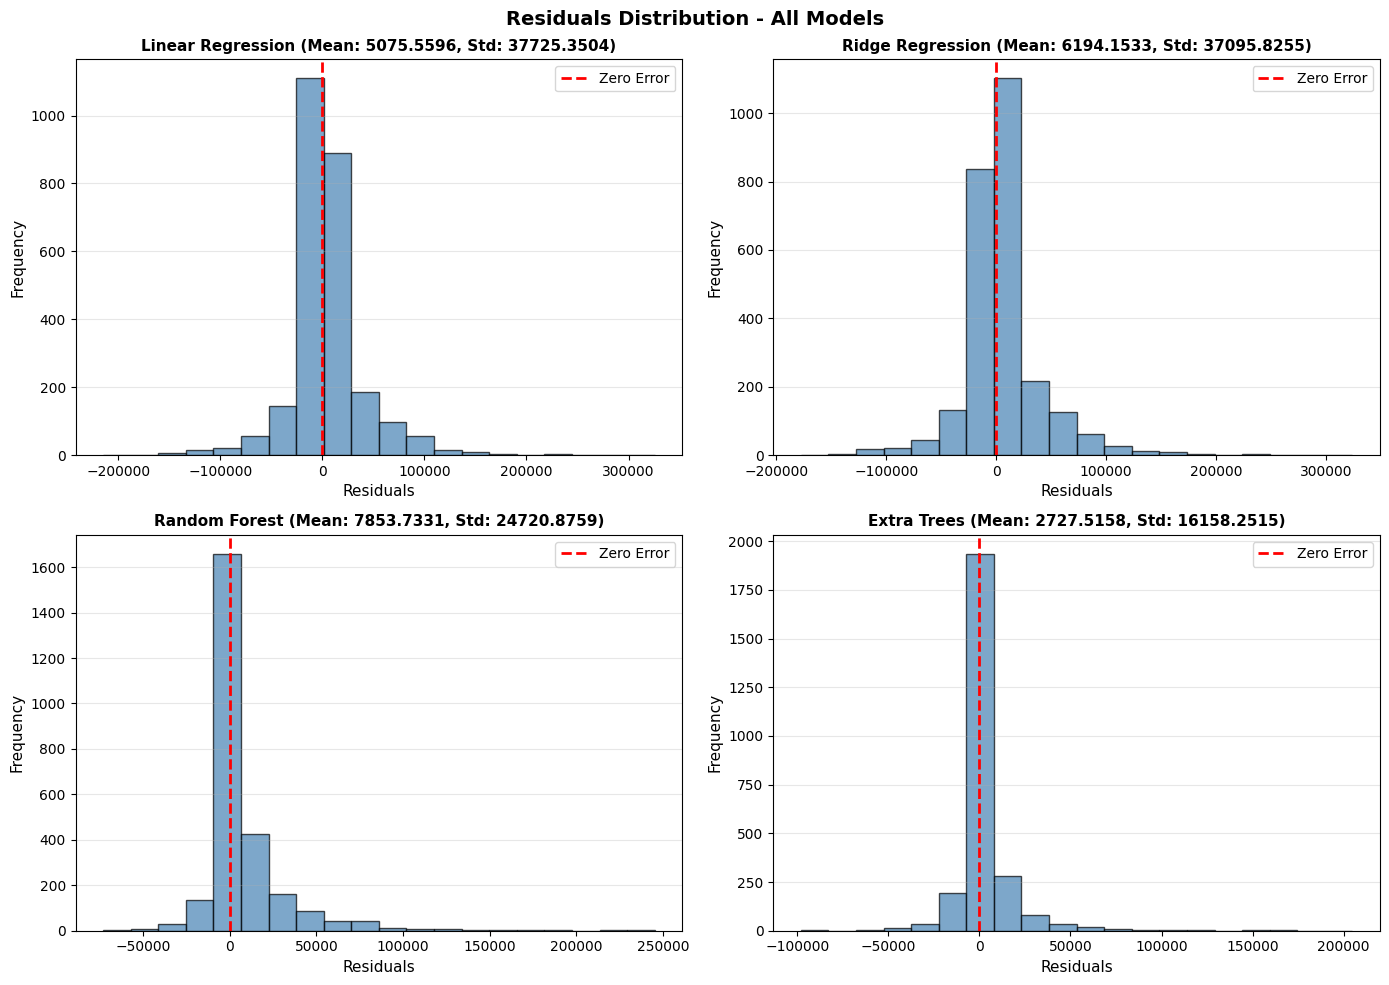

✓ Biểu đồ residuals distribution đã vẽ


In [9]:
# Vẽ residuals distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, model_name in enumerate(model_names[:4]):
    resid = residuals[model_name]
    
    axes[idx].hist(resid, bins=20, alpha=0.7, edgecolor='black', color='steelblue')
    axes[idx].axvline(x=0, color='r', linestyle='--', linewidth=2, label='Zero Error')
    
    axes[idx].set_xlabel('Residuals', fontsize=11)
    axes[idx].set_ylabel('Frequency', fontsize=11)
    axes[idx].set_title(
        f'{model_name} (Mean: {resid.mean():.4f}, Std: {resid.std():.4f})',
        fontsize=11, fontweight='bold'
    )
    axes[idx].legend()
    axes[idx].grid(alpha=0.3, axis='y')

plt.suptitle('Residuals Distribution - All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Biểu đồ residuals distribution đã vẽ")

## 4. Q-Q Plots for Best Model

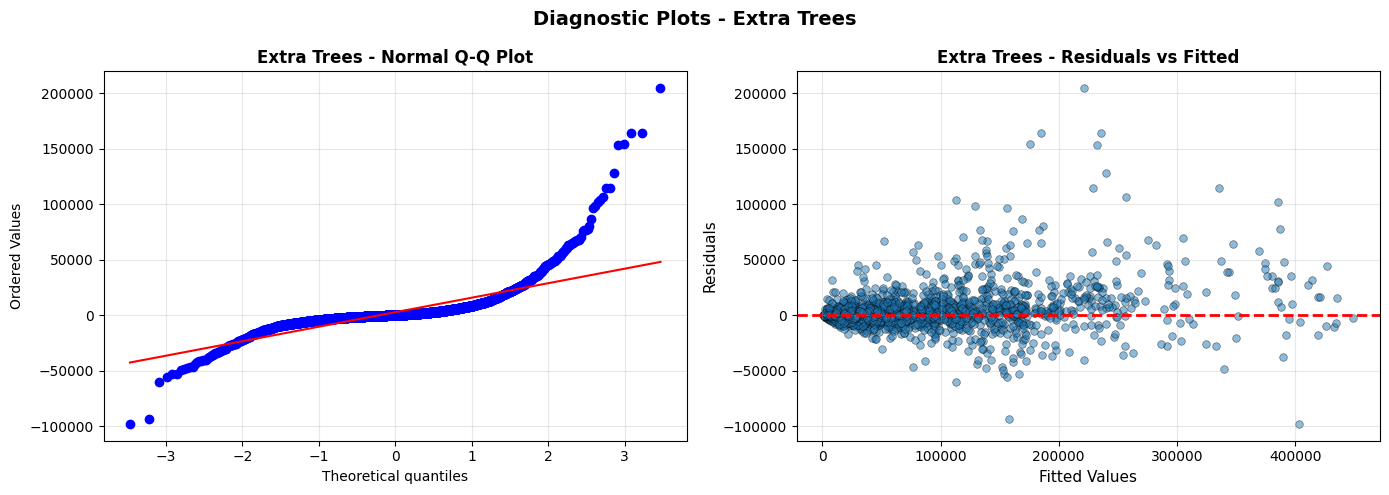

✓ Q-Q plots cho best model (Extra Trees) đã vẽ


In [10]:
# Q-Q plot cho best model
best_model_name = metrics_df.index[0]
best_residuals = residuals[best_model_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Q-Q plot
stats.probplot(best_residuals, dist="norm", plot=axes[0])
axes[0].set_title(f'{best_model_name} - Normal Q-Q Plot', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# Residuals vs Fitted
y_pred_best = predictions[best_model_name]
axes[1].scatter(y_pred_best, best_residuals, alpha=0.5, s=30, edgecolors='k', linewidth=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Fitted Values', fontsize=11)
axes[1].set_ylabel('Residuals', fontsize=11)
axes[1].set_title(f'{best_model_name} - Residuals vs Fitted', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.suptitle(f'Diagnostic Plots - {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"✓ Q-Q plots cho best model ({best_model_name}) đã vẽ")

## 5. Error Analysis

# Tính lỗi tuyệt đối từng sample
y_pred_best = predictions[best_model_name]
absolute_errors = np.abs(y_test.values - y_pred_best)
percentage_errors = np.abs((y_test.values - y_pred_best) / y_test.values) * 100

print("\n" + "="*80)
print("📊 ERROR ANALYSIS")
print("="*80)

print(f"\n{best_model_name}:")
print("   Absolute Errors:")
print(f"      Mean:   {absolute_errors.mean():.4f}")
print(f"      Std:    {absolute_errors.std():.4f}")
print(f"      Min:    {absolute_errors.min():.4f}")
print(f"      Max:    {absolute_errors.max():.4f}")
print(f"      Median: {np.median(absolute_errors):.4f}")

print("\n   Percentage Errors (%):")
print(f"      Mean:   {percentage_errors.mean():.2f}%")
print(f"      Std:    {percentage_errors.std():.2f}%")
print(f"      Min:    {percentage_errors.min():.2f}%")
print(f"      Max:    {percentage_errors.max():.2f}%")
print(f"      Median: {np.median(percentage_errors):.2f}%")

In [11]:
# Tính lỗi tuyệt đối từng sample
y_pred_best = predictions[best_model_name]
absolute_errors = np.abs(y_test.values - y_pred_best)
percentage_errors = np.abs((y_test.values - y_pred_best) / y_test.values) * 100

print("\n" + "="*80)
print("📊 ERROR ANALYSIS")
print("="*80)

print(f"\n{best_model_name}:")
print("   Absolute Errors:")
print(f"      Mean:   {absolute_errors.mean():.4f}")
print(f"      Std:    {absolute_errors.std():.4f}")
print(f"      Min:    {absolute_errors.min():.4f}")
print(f"      Max:    {absolute_errors.max():.4f}")
print(f"      Median: {np.median(absolute_errors):.4f}")

print("\n   Percentage Errors (%):")
print(f"      Mean:   {percentage_errors.mean():.2f}%")
print(f"      Std:    {percentage_errors.std():.2f}%")
print(f"      Min:    {percentage_errors.min():.2f}%")
print(f"      Max:    {percentage_errors.max():.2f}%")
print(f"      Median: {np.median(percentage_errors):.2f}%")


📊 ERROR ANALYSIS

Extra Trees:
   Absolute Errors:
      Mean:   7830.0393
      Std:    14395.1005
      Min:    2.2993
      Max:    204797.2285
      Median: 3105.4554

   Percentage Errors (%):
      Mean:   14.72%
      Std:    24.32%
      Min:    0.00%
      Max:    380.74%
      Median: 8.01%


In [12]:
# Top 10 worst predictions
worst_idx = np.argsort(absolute_errors)[::-1][:10]

worst_predictions = pd.DataFrame({
    'Actual': y_test.values[worst_idx],
    'Predicted': y_pred_best[worst_idx],
    'Absolute_Error': absolute_errors[worst_idx],
    'Percentage_Error_%': percentage_errors[worst_idx]
}).reset_index(drop=True)

print("\n" + "="*80)
print("🔴 TOP 10 WORST PREDICTIONS")
print("="*80)
display(worst_predictions)


🔴 TOP 10 WORST PREDICTIONS


,Actual,Predicted,Absolute_Error,Percentage_Error_%
0,426047,221249.771453,204797.228547,48.069163
1,349594,185268.522878,164325.477122,47.004662
2,400000,236025.319323,163974.680677,40.993670
3,329827,175725.512578,154101.487422,46.721914
4,385818,232131.697561,153686.302439,39.833886
5,367969,240084.319896,127884.680104,34.754199
6,451015,335879.934985,115135.065015,25.527990
7,343433,228631.484686,114801.515314,33.427631
8,363561,256602.051472,106958.948528,29.419808
9,217784,113432.440720,104351.559280,47.915163


# Top 10 best predictions
best_idx = np.argsort(absolute_errors)[:10]

best_predictions = pd.DataFrame({
    'Actual': y_test.values[best_idx],
    'Predicted': y_pred_best[best_idx],
    'Absolute_Error': absolute_errors[best_idx],
    'Percentage_Error_%': percentage_errors[best_idx]
}).reset_index(drop=True)

print("\n" + "="*80)
print("🟢 TOP 10 BEST PREDICTIONS")
print("="*80)
display(best_predictions)

In [13]:
# Top 10 best predictions
best_idx = np.argsort(absolute_errors)[:10]

best_predictions = pd.DataFrame({
    'Actual': y_test.values[best_idx],
    'Predicted': y_pred_best[best_idx],
    'Absolute_Error': absolute_errors[best_idx],
    'Percentage_Error_%': percentage_errors[best_idx]
}).reset_index(drop=True)

print("\n" + "="*80)
print("🟢 TOP 10 BEST PREDICTIONS")
print("="*80)
display(best_predictions)


🟢 TOP 10 BEST PREDICTIONS


,Actual,Predicted,Absolute_Error,Percentage_Error_%
0,15139,15136.700736,2.299264,0.015188
1,7641,7643.972168,2.972168,0.038898
2,95150,95154.068885,4.068885,0.004276
3,56503,56509.429822,6.429822,0.011380
4,7001,6994.413697,6.586303,0.094077
5,12692,12698.763013,6.763013,0.053286
6,9161,9151.492724,9.507276,0.103780
7,63415,63425.950276,10.950276,0.017268
8,5074,5062.998625,11.001375,0.216819
9,17274,17286.095425,12.095425,0.070021


## 6. Model Comparison Summary

# Tóm tắt so sánh models
print("\n" + "="*80)
print("📊 FINAL MODEL COMPARISON")
print("="*80)

comparison_df = metrics_df.copy()

# Format columns
for col in ['MAE', 'RMSE', 'MSE', 'R2', 'MAPE']:
    if col in comparison_df.columns:
        comparison_df[col] = comparison_df[col].apply(lambda x: f"{x:.4f}")

display(comparison_df)

print("\n\n📈 RANKING:")
for idx, (model_name, row) in enumerate(metrics_df.iterrows(), 1):
    status = "🏆" if idx == 1 else f"#{idx}"
    print(f"   {status} {model_name:20s} - R²: {row['R2']:.4f}, RMSE: {row['RMSE']:.4f}")

In [14]:
# Tóm tắt so sánh models
print("\n" + "="*80)
print("📊 FINAL MODEL COMPARISON")
print("="*80)

comparison_df = metrics_df.copy()

for col in ['MAE', 'RMSE', 'MSE', 'R2', 'MAPE']:
    if col in comparison_df.columns:
        comparison_df[col] = comparison_df[col].apply(lambda x: f"{x:.4f}")

display(comparison_df)

print("\n\n📈 RANKING:")
for idx, (model_name, row) in enumerate(metrics_df.iterrows(), 1):
    status = "🏆" if idx == 1 else f"#{idx}"
    print(f"   {status} {model_name:20s} - R²: {row['R2']:.4f}, RMSE: {row['RMSE']:.4f}")


📊 FINAL MODEL COMPARISON


,Model,MAE,RMSE,MSE,R2,MAPE,MASE,MBE,Median_AE
Extra Trees,Extra Trees,7830.0393,16386.8372,268528432.8069,0.9591,0.1472,0.099204,2727.515793,3105.455369
Hist Gradient Boosting,Hist Gradient Boosting,13092.2194,24645.4369,607397560.6469,0.9075,0.2367,0.165874,4182.799206,5573.520346
Random Forest,Random Forest,12902.2806,25938.4431,672802830.4425,0.8975,0.2221,0.163468,7853.733101,4898.655061
Ridge Regression,Ridge Regression,21871.6286,37609.4111,1414467803.6520,0.7845,0.4619,0.277107,6194.153275,10477.321648
Linear Regression,Linear Regression,21961.5706,38065.2514,1448963365.7052,0.7793,0.4570,0.278246,5075.559576,10356.374385




📈 RANKING:
   🏆 Extra Trees          - R²: 0.9591, RMSE: 16386.8372
   #2 Hist Gradient Boosting - R²: 0.9075, RMSE: 24645.4369
   #3 Random Forest        - R²: 0.8975, RMSE: 25938.4431
   #4 Ridge Regression     - R²: 0.7845, RMSE: 37609.4111
   #5 Linear Regression    - R²: 0.7793, RMSE: 38065.2514


## 7. Export Results

# Lưu kết quả
output_dir = Path('../outputs/tables')
output_dir.mkdir(parents=True, exist_ok=True)

# Lưu metrics
metrics_csv = output_dir / 'model_metrics.csv'
metrics_df.to_csv(metrics_csv)

# Lưu predictions
predictions_df = pd.DataFrame({
    'Actual': y_test.values,
})

for model_name, y_pred in predictions.items():
    predictions_df[f'Pred_{model_name}'] = y_pred

predictions_csv = output_dir / 'predictions.csv'
predictions_df.to_csv(predictions_csv, index=False)

print(f"✓ Kết quả lưu vào: {output_dir}")
print(f"   • {metrics_csv.name}")
print(f"   • {predictions_csv.name}")

In [15]:
# Lưu kết quả
output_dir = Path('../outputs/tables')
output_dir.mkdir(parents=True, exist_ok=True)

metrics_csv = output_dir / 'model_metrics.csv'
metrics_df.to_csv(metrics_csv)

predictions_df = pd.DataFrame({'Actual': y_test.values})
for model_name, y_pred in predictions.items():
    predictions_df[f'Pred_{model_name}'] = y_pred

predictions_csv = output_dir / 'predictions.csv'
predictions_df.to_csv(predictions_csv, index=False)

print(f"✓ Kết quả lưu vào: {output_dir}")
print(f"   • {metrics_csv.name}")
print(f"   • {predictions_csv.name}")

✓ Kết quả lưu vào: ..\outputs\tables
   • model_metrics.csv
   • predictions.csv


# Tạo report markdown
reporter = EvaluationReporter(output_dir=str(output_dir))

report_path = Path('../outputs/EVALUATION_REPORT.md')
report_path.parent.mkdir(parents=True, exist_ok=True)

with open(report_path, 'w', encoding='utf-8') as f:
    f.write("# Model Evaluation Report\n\n")
    f.write("## Executive Summary\n\n")
    f.write(f"Best Model: **{best_model_name}**\n\n")
    f.write(f"- R² Score: {metrics_df.loc[best_model_name, 'R2']:.4f}\n")
    f.write(f"- MAE: {metrics_df.loc[best_model_name, 'MAE']:.4f}\n")
    f.write(f"- RMSE: {metrics_df.loc[best_model_name, 'RMSE']:.4f}\n")
    f.write(f"- MAPE: {metrics_df.loc[best_model_name, 'MAPE']:.4f}%\n\n")
    
    f.write("## Model Comparison\n\n")
    f.write(metrics_df.to_markdown())
    f.write("\n\n")
    
    f.write("## Key Findings\n\n")
    f.write(f"1. The {best_model_name} model achieved the highest R² score of {metrics_df.loc[best_model_name, 'R2']:.4f}\n")
    f.write(f"2. Average prediction error (MAPE): {metrics_df.loc[best_model_name, 'MAPE']:.2f}%\n")
    f.write(f"3. Mean Absolute Error: {metrics_df.loc[best_model_name, 'MAE']:.4f}\n")
    f.write(f"4. Root Mean Squared Error: {metrics_df.loc[best_model_name, 'RMSE']:.4f}\n\n")

print(f"\n✓ Report lưu vào: {report_path}")

In [16]:
# Tạo report markdown
reporter = EvaluationReporter(output_dir=str(output_dir))

report_path = Path('../outputs/EVALUATION_REPORT.md')
report_path.parent.mkdir(parents=True, exist_ok=True)

with open(report_path, 'w', encoding='utf-8') as f:
    f.write("# Model Evaluation Report\n\n")
    f.write("## Executive Summary\n\n")
    f.write(f"Best Model: **{best_model_name}**\n\n")
    f.write(f"- R² Score: {metrics_df.loc[best_model_name, 'R2']:.4f}\n")
    f.write(f"- MAE: {metrics_df.loc[best_model_name, 'MAE']:.4f}\n")
    f.write(f"- RMSE: {metrics_df.loc[best_model_name, 'RMSE']:.4f}\n")
    f.write(f"- MAPE: {metrics_df.loc[best_model_name, 'MAPE']:.4f}%\n\n")
    f.write("## Model Comparison\n\n")
    f.write(metrics_df.to_markdown())
    f.write("\n\n")
    f.write("## Key Findings\n\n")
    f.write(f"1. The {best_model_name} model achieved the highest R² score of {metrics_df.loc[best_model_name, 'R2']:.4f}\n")
    f.write(f"2. Average prediction error (MAPE): {metrics_df.loc[best_model_name, 'MAPE']:.2f}%\n")
    f.write(f"3. Mean Absolute Error: {metrics_df.loc[best_model_name, 'MAE']:.4f}\n")
    f.write(f"4. Root Mean Squared Error: {metrics_df.loc[best_model_name, 'RMSE']:.4f}\n\n")

print(f"\n✓ Report lưu vào: {report_path}")


✓ Report lưu vào: ..\outputs\EVALUATION_REPORT.md


# Excel export với reporter
excel_path = output_dir / 'model_evaluation.xlsx'
reporter.export_results_excel(
    {
        'metrics': metrics_df.reset_index().rename(columns={'index': 'Model'}),
        'predictions': predictions_df
    },
    'model_evaluation.xlsx'
 )

print(f"\n✓ Excel report lưu vào: {excel_path}")

In [17]:
# Excel export với reporter
excel_path = output_dir / 'model_evaluation.xlsx'
reporter.export_results_excel(
    {
        'metrics': metrics_df.reset_index().rename(columns={'index': 'Model'}),
        'predictions': predictions_df
    },
    'model_evaluation.xlsx'
 )

print(f"\n✓ Excel report lưu vào: {excel_path}")

✓ Đã xuất Excel (openpyxl): ..\outputs\tables\model_evaluation.xlsx

✓ Excel report lưu vào: ..\outputs\tables\model_evaluation.xlsx


# Tóm tắt cuối cùng
print("\n" + "="*80)
print("✅ EVALUATION HOÀN TẤT")
print("="*80)

print(f"\n🏆 BEST MODEL: {best_model_name}")
print("\n📊 Performance Metrics:")
print(f"   • R² Score:  {metrics_df.loc[best_model_name, 'R2']:.4f}")
print(f"   • MAE:       {metrics_df.loc[best_model_name, 'MAE']:.4f}")
print(f"   • RMSE:      {metrics_df.loc[best_model_name, 'RMSE']:.4f}")
print(f"   • MAPE:      {metrics_df.loc[best_model_name, 'MAPE']:.4f}%")

print("\n📁 Output Files:")
print(f"   • {metrics_csv}")
print(f"   • {predictions_csv}")
print(f"   • {report_path}")
print(f"   • {excel_path}")

print("\n✅ Pipeline evaluation successfully completed!")

In [18]:
# Tóm tắt cuối cùng
print("\n" + "="*80)
print("✅ EVALUATION HOÀN TẤT")
print("="*80)

print(f"\n🏆 BEST MODEL: {best_model_name}")
print("\n📊 Performance Metrics:")
print(f"   • R² Score:  {metrics_df.loc[best_model_name, 'R2']:.4f}")
print(f"   • MAE:       {metrics_df.loc[best_model_name, 'MAE']:.4f}")
print(f"   • RMSE:      {metrics_df.loc[best_model_name, 'RMSE']:.4f}")
print(f"   • MAPE:      {metrics_df.loc[best_model_name, 'MAPE']:.4f}%")

print("\n📁 Output Files:")
print(f"   • {metrics_csv}")
print(f"   • {predictions_csv}")
print(f"   • {report_path}")
print(f"   • {excel_path}")

print("\n✅ Pipeline evaluation successfully completed!")


✅ EVALUATION HOÀN TẤT

🏆 BEST MODEL: Extra Trees

📊 Performance Metrics:
   • R² Score:  0.9591
   • MAE:       7830.0393
   • RMSE:      16386.8372
   • MAPE:      0.1472%

📁 Output Files:
   • ..\outputs\tables\model_metrics.csv
   • ..\outputs\tables\predictions.csv
   • ..\outputs\EVALUATION_REPORT.md
   • ..\outputs\tables\model_evaluation.xlsx

✅ Pipeline evaluation successfully completed!


In [6]:
# Quick optimization summary
summary_cols = [c for c in ['R2', 'MAE', 'RMSE', 'MAPE'] if c in metrics_df.columns]
summary_df = metrics_df[summary_cols].sort_values('R2', ascending=False).copy()
print('Top models by R2 (optimized pipeline):')
display(summary_df.head(5))
print(f"Best model: {summary_df.index[0]} | R2 = {summary_df.iloc[0]['R2']:.4f}")

Top models by R2 (optimized pipeline):


,R2,MAE,RMSE,MAPE
Extra Trees,0.959096,7830.039274,16386.837181,0.14719
Hist Gradient Boosting,0.907476,13092.219445,24645.436913,0.236662
Random Forest,0.897513,12902.28064,25938.4431,0.22213
Ridge Regression,0.784536,21871.628636,37609.411105,0.461949
Linear Regression,0.779282,21961.570635,38065.25142,0.456978


Best model: Extra Trees | R2 = 0.9591
